##
EXAMPLE 1: Application of Newton Cooling Law ==> Predict the cooling of a cup of coffee

Consider a hott cup of coffee at initial temperature $T_{\circ}$ and subject to the room temperature $T_{\infty}$. As expected from the Newton law of cooling, coffee's temperature will change in time, i.e., $T(t)$ and expressed as
<br/>
$\begin{equation}
     \displaystyle\frac{dT}{dt} = -\displaystyle\frac{hA_{s}}{m C_{p}}\left(T-T_{\infty}\right),
\end{equation}$
<br/>
where $T$ and $t$ are temperature and time, respectively. $h$, $A_{s}$ and $T_{\infty}$ are the interphase heat transfer coefficient, surface area and environmental temperature, respectively. Finally, $m C_{p}$ is the effective heat capacity, and if the heat capacity of the cup is large enough, then

$m C_{p} \Longrightarrow m_{\text{cup}}C_{p,\text{cup}} + m_{\text{coffee}} C_{p,\text{coffee}}$.

We should also define the time constant $\tau$ as

$\begin{equation}
   \tau = \displaystyle\frac{m C_{p}}{h A_{s}}.
\end{equation}$

This leads to
<br/>
$\displaystyle\frac{dT}{dt} = -\tau^{-1}\left(T-T_{\infty}\right)$.
<br/>

Considering $\theta(t) = \left(T-T_{\infty}\right)$, the differenctial equation may now be expressed as
<br/>
$\begin{equation}
   \displaystyle\frac{d\theta}{dt} = -\displaystyle\frac{\theta}{\tau},
\end{equation}$

which could be integrated to

$\theta(t) = \theta_{\circ}e^{-t/\tau}$,

where $\theta_{\circ} = \theta(t=0)$. Thus

<center/>
$\begin{equation}
    T(t) = T_{\infty} + \left(T_{\circ} - T_{\infty}\right) e^{-t/\tau}
\end{equation}$


In [1]:

"""
    Generating synthetic data
"""
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Physics parameters
T_infty = 25.0  # Room temperature (degC)
T0 = 60.0       # Initial coffee temperature (degC)
tau = 0.2       # Time constant

# True analytical solution
def true_solution(t):
    return T_infty + (T0 - T_infty)*np.exp(-tau*t)

# Generate time data (t<20)
t_min, t_max = 0.0, 20.0; num_data_points = 10
t_data = np.linspace(t_min, t_max, num_data_points)

# Generate noisy temperature measurements
np.random.seed(0)
noise_level = 2.0  # ±2°C measurement error

"""
     Generating temperature data, based on both the analytical solution and
         a perturbation.
"""
T_data_exact = true_solution(t_data)
T_data_noisy = T_data_exact + noise_level*np.random.randn(len(t_data))

"""
    Convert data to PyTorch tensors
"""
t_data_tensor = torch.tensor(t_data, dtype=torch.float32).view(-1, 1)
T_data_tensor = torch.tensor(T_data_noisy, dtype=torch.float32).view(-1, 1)

In [2]:
"""
    Defining the PINN class: It was initialised through a linear activation function
      (AF) through n hidden layers. The linear activation function (identity function)
      transfer the input directly to the output without making any changes, i.e.,
      f(x) = x. Then it uses a second AF, which could be either activation functions:
        (a) ReLU (Rectified Linear Unit): it is defined as f(x) = max(0, x).
            It turns negative inputs into zero while letting positive inputs
            pass through unchanged.
        (b) Tanh (hyperbolic tangent): it maps input values to an S-shaped curve
            ranging between -1 and 1.
"""

class CoffeePINN(nn.Module):
    def __init__(self):
        n = 20 # number of hidden neurons
        super(CoffeePINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, n),  # 1 input (time), n hidden neurons
            nn.ReLU(),
            #nn,Tanh(),
            nn.Linear(n, n),
            nn.ReLU(),
            #nn,Tanh(),
            nn.Linear(n, 1)   # 1 output (temperature)
        )

    def forward(self, t):
        return self.net(t)

ModelCoffee = CoffeePINN()

In [3]:

"""
    Defining the physics loss
"""
def derivative(y, x):
    """Computes dy/dx using autograd"""
    return torch.autograd.grad(y, x,
                             grad_outputs=torch.ones_like(y),
                             create_graph=True)[0]

def physics_loss(ModelCoffee, t):
    """Physics loss: dT/dt = -k*(T - T_infty)"""
    t.requires_grad_(True)

    # Get prediction and derivative
    T = ModelCoffee(t)
    dT_dt = derivative(T, t)

    # Governing equation residual
    residual = dT_dt + tau*(T - T_infty)
    return torch.mean(residual**2)

In [4]:

"""
   Defining data and initial condition losses
"""
def data_loss(ModelCoffee, t_data, T_data):
    """Mean squared error (MSE) between predictions and measurements"""
    T_pred = ModelCoffee(t_data)
    return torch.mean((T_pred - T_data)**2)

def initial_condition_loss(ModelCoffee):
    """Initial condition: T(0) = T0"""
    t0 = torch.zeros(1, 1, dtype=torch.float32)
    T_pred = ModelCoffee(t0)
    return (T_pred - T0).pow(2).mean()

In [5]:

"""
   Train the PINN
"""
optimizer = torch.optim.Adam(ModelCoffee.parameters(), lr=0.01) # lr: learning rate (default 1e-3)
"""
  Try the following
optimizer = torch.optim.Adam(ModelCoffee.parameters(), lr=1.e-5)
optimizer = torch.optim.Adam(ModelCoffee.parameters(), lr=9.e-1)
"""

# Loss weights (you can adjust these)
lambda_data = 1.0
lambda_ode = 1.0
lambda_ic = 1.0

### Number of Epochs
num_epochs = 8000
print_every = 200

ModelCoffee.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Compute all loss components
    l_data = data_loss(ModelCoffee, t_data_tensor, T_data_tensor)
    l_ode = physics_loss(ModelCoffee, t_data_tensor)
    l_ic = initial_condition_loss(ModelCoffee)

    # Combined loss
    loss = lambda_data*l_data + lambda_ode*l_ode + lambda_ic*l_ic

    # Backpropagation
    loss.backward()
    optimizer.step()

    # Print progress
    if (epoch + 1) % print_every == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, "
              f"Total Loss = {loss.item():.4f}, "
              f"Data Loss = {l_data.item():.4f}, "
              f"ODE Loss = {l_ode.item():.4f}, "
              f"IC Loss = {l_ic.item():.4f}")


Epoch 200/8000, Total Loss = 3.8131, Data Loss = 2.5498, ODE Loss = 1.1744, IC Loss = 0.0889
Epoch 400/8000, Total Loss = 3.1934, Data Loss = 2.2377, ODE Loss = 0.8501, IC Loss = 0.1055
Epoch 600/8000, Total Loss = 2.9495, Data Loss = 2.1001, ODE Loss = 0.7467, IC Loss = 0.1027
Epoch 800/8000, Total Loss = 2.9335, Data Loss = 2.1069, ODE Loss = 0.7271, IC Loss = 0.0996
Epoch 1000/8000, Total Loss = 2.7202, Data Loss = 2.0936, ODE Loss = 0.5266, IC Loss = 0.1000
Epoch 1200/8000, Total Loss = 2.6559, Data Loss = 2.0848, ODE Loss = 0.4757, IC Loss = 0.0955
Epoch 1400/8000, Total Loss = 2.6910, Data Loss = 2.0831, ODE Loss = 0.5144, IC Loss = 0.0935
Epoch 1600/8000, Total Loss = 2.6702, Data Loss = 2.0944, ODE Loss = 0.4796, IC Loss = 0.0961
Epoch 1800/8000, Total Loss = 2.6296, Data Loss = 2.0823, ODE Loss = 0.4547, IC Loss = 0.0925
Epoch 2000/8000, Total Loss = 2.6321, Data Loss = 2.0926, ODE Loss = 0.4475, IC Loss = 0.0920
Epoch 2200/8000, Total Loss = 2.6211, Data Loss = 2.0878, ODE Lo

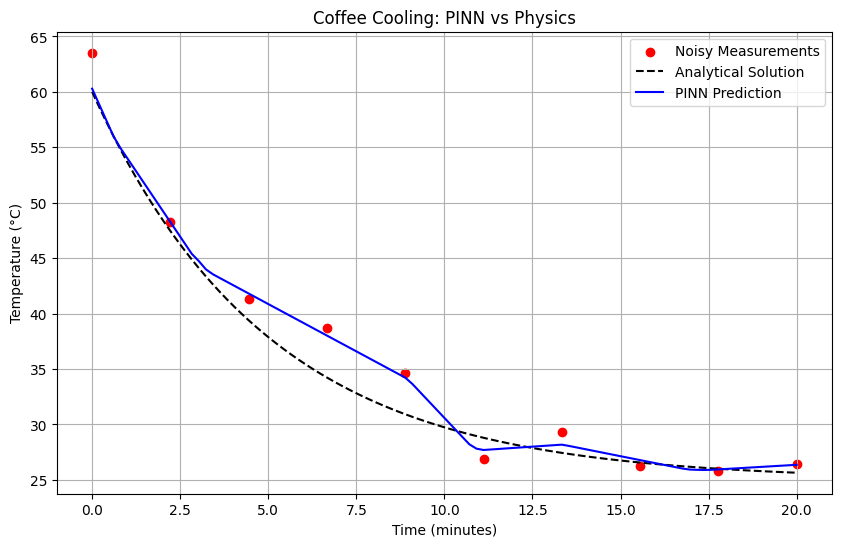

In [6]:
"""
   Visualise the results
"""
ModelCoffee.eval()
t_plot = np.linspace(t_min, t_max, 100).reshape(-1, 1)
t_plot_tensor = torch.tensor(t_plot, dtype=torch.float32)
T_pred_plot = ModelCoffee(t_plot_tensor).detach().numpy()

# True solution for comparison
T_true_plot = true_solution(t_plot)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(t_data, T_data_noisy, color='red', label='Noisy Measurements')
plt.plot(t_plot, T_true_plot, 'k--', label='Analytical Solution')
plt.plot(t_plot, T_pred_plot, 'b', label='PINN Prediction')
plt.xlabel('Time (minutes)')
plt.ylabel('Temperature (°C)')
plt.title('Coffee Cooling: PINN vs Physics')
plt.legend()
plt.grid(True)
plt.show()